# SinoNom OCR — Visual Layout Playground

**HCMUS NaturalLanguageProcessing — MidTerm Project**  
**An Nam Nhất Thống Chí (HVH_004)**

---

This playground notebook allows you to select any of the **107 page images** and visually overlay the OCR-detected character bounding boxes and the grouped columns generated by our **Adaptive Horizontal Thresholding (AHT)** clustering engine.


## 0 · Environment & Imports


In [14]:
# ─── Detect environment & Set project root ─────────────────────────────────
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print(f"Running in Google Colab: {IN_COLAB}")

if IN_COLAB:
    # Attempt to locate mounted Google Drive
    if os.path.exists("/content/drive/MyDrive"):
        PROJECT_ROOT = "/content/drive/MyDrive/SinoNomOCR/HVH_004"
    else:
        PROJECT_ROOT = "/content"
else:
    # Local Jupyter notebook running inside the notebooks/ directory
    PROJECT_ROOT = os.path.abspath("..")

os.chdir(PROJECT_ROOT)
print(f"🎯 Project root set to: {PROJECT_ROOT}")
print(f"🔄 Current working directory: {os.getcwd()}")

Running in Google Colab: False
🎯 Project root set to: /Users/KhangDS/Programing/HCMUS_Code/NaturalLanguageProcessing_code
🔄 Current working directory: /Users/KhangDS/Programing/HCMUS_Code/NaturalLanguageProcessing_code


In [16]:
# ─── Load visualization dependencies ───────────────────────────────────────
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Configure Matplotlib to support CJK characters on macOS
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Arial Unicode MS', 
    'Heiti TC', 
    'Heiti SC', 
    'Songti TC', 
    'Songti SC', 
    'STSong', 
    'SimSun', 
    'sans-serif'
]
plt.rcParams['axes.unicode_minus'] = False

# Add src/ to path so we can import BoundingBox and Column if needed
SRC_PATH = Path(PROJECT_ROOT) / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("✅ Core visualization libraries & macOS CJK fonts configured.")

✅ Core visualization libraries & macOS CJK fonts configured.


## 1 · Path Configuration & Layout Data Loading


In [17]:
# ─── Setup path directories ───────────────────────────────────────────────
LOCAL_DRIVE_PATH = Path("/Users/KhangDS/Library/CloudStorage/GoogleDrive-gausseuler159357@gmail.com/My Drive/SinoNomOCR/HVH_004")
COLAB_DRIVE_PATH = Path("/content/drive/MyDrive/SinoNomOCR/HVH_004")

if IN_COLAB and COLAB_DRIVE_PATH.exists():
    DATA_DIR = COLAB_DRIVE_PATH / "data"
elif LOCAL_DRIVE_PATH.exists():
    DATA_DIR = LOCAL_DRIVE_PATH / "data"
else:
    DATA_DIR = Path(PROJECT_ROOT) / "data"

RAW_IMAGES_DIR = DATA_DIR / "raw_images"
LAYOUT_JSON_PATH = DATA_DIR / "ocr_layout_output.json"

print(f"Raw images dir: {RAW_IMAGES_DIR}")
print(f"Layout JSON    : {LAYOUT_JSON_PATH}")

# Check if layout JSON exists
if not LAYOUT_JSON_PATH.exists():
    raise FileNotFoundError(f"❌ Layout output file not found at {LAYOUT_JSON_PATH}. Please run Phase 2 first.")

with open(LAYOUT_JSON_PATH, encoding="utf-8") as fh:
    corpus_layout = json.load(fh)

print(f"\n✅ Successfully loaded layout geometries of {len(corpus_layout)} chapters.")

Raw images dir: /Users/KhangDS/Library/CloudStorage/GoogleDrive-gausseuler159357@gmail.com/My Drive/SinoNomOCR/HVH_004/data/raw_images
Layout JSON    : /Users/KhangDS/Library/CloudStorage/GoogleDrive-gausseuler159357@gmail.com/My Drive/SinoNomOCR/HVH_004/data/ocr_layout_output.json

✅ Successfully loaded layout geometries of 1 chapters.


## 2 · Layout Visualization Helper

This function draws character polygons (bounding boxes) on top of the original scanned page, color-codes them by column identifier, and prints the recognized vertical text column-by-column beside the image.


In [18]:
def visualize_page_layout(page_num: int, chapter_num: int = 1):
    """
    Visualizes character bounding boxes and column layouts on the scanned page.
    
    Args:
        page_num: 1-based page index (e.g. 1 to 107)
        chapter_num: 1-based chapter index
    """
    # 1. Locate and read the image
    img_path = RAW_IMAGES_DIR / f"page_{page_num:03d}.jpg"
    if not img_path.exists():
        print(f"❌ Error: Scanned image not found at: {img_path}")
        return
        
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Get layout data
    ch_idx = chapter_num - 1
    if ch_idx >= len(corpus_layout):
        print(f"❌ Error: Chapter {chapter_num} not found in layout data.")
        return
        
    ch_data = corpus_layout[ch_idx]
    # Find the page data matching the requested page number
    pg_data = None
    for p in ch_data:
        if p["page"] == page_num:
            pg_data = p
            break
            
    if not pg_data:
        print(f"❌ Error: Page {page_num} not found in Chapter {chapter_num} layout data.")
        return
        
    columns = pg_data["columns"]
    
    # 3. Create unique distinct colors for each column for clarity
    np.random.seed(1337)  # Stable colors
    col_colors = [tuple(int(x) for x in np.random.randint(50, 220, size=3)) for _ in range(len(columns))]
    
    overlay = img.copy()
    
    # 4. Draw character boxes
    for col_idx, col in enumerate(columns):
        color = col_colors[col_idx]
        for box in col["boxes"]:
            poly = np.array(box["raw_polygon"], dtype=np.int32)
            # Draw outline
            cv2.polylines(overlay, [poly], isClosed=True, color=color, thickness=2)
            
            # Fill a light transparent color inside the box
            cv2.fillPoly(overlay, [poly], color=color)
            
    # Alpha blend to make the fill translucent
    alpha = 0.25
    blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    
    # 5. Display Plot
    fig, axes = plt.subplots(1, 2, figsize=(18, 12), gridspec_kw={'width_ratios': [2.2, 1]})
    
    axes[0].imshow(blended)
    axes[0].set_title(f"An Nam Nhất Thống Chí — Page {page_num:03d} Layout Clustering (AHT)", fontsize=15, pad=15, fontweight='bold')
    axes[0].axis("off")
    
    # Sidebar text assembly
    axes[1].axis("off")
    sidebar_lines = [
        f"PAGE {page_num:03d} LAYOUT SUMMARY",
        f"--------------------------------------",
        f"Detected Columns: {len(columns)}\n",
        "VĂN BẢN TRÍCH XUẤT (Cột phải sang trái):",
        "======================================"
    ]
    
    for col_idx, col in enumerate(columns):
        col_text = "".join([b["text"] for b in col["boxes"]])
        sidebar_lines.append(f"Cột {col_idx + 1:02d}: {col_text}\n")
        
    axes[1].text(0.02, 0.98, "\n".join(sidebar_lines), fontsize=11,
                 verticalalignment='top', bbox=dict(boxstyle='round,pad=1', facecolor='#FAFAFA', alpha=0.95, edgecolor='#DDDDDD'))

    plt.tight_layout()
    plt.show()

## 3 · Run Playground Visualization

Simply adjust `page_num` (1 to 107) below and run the cell to visualize any page in the book.


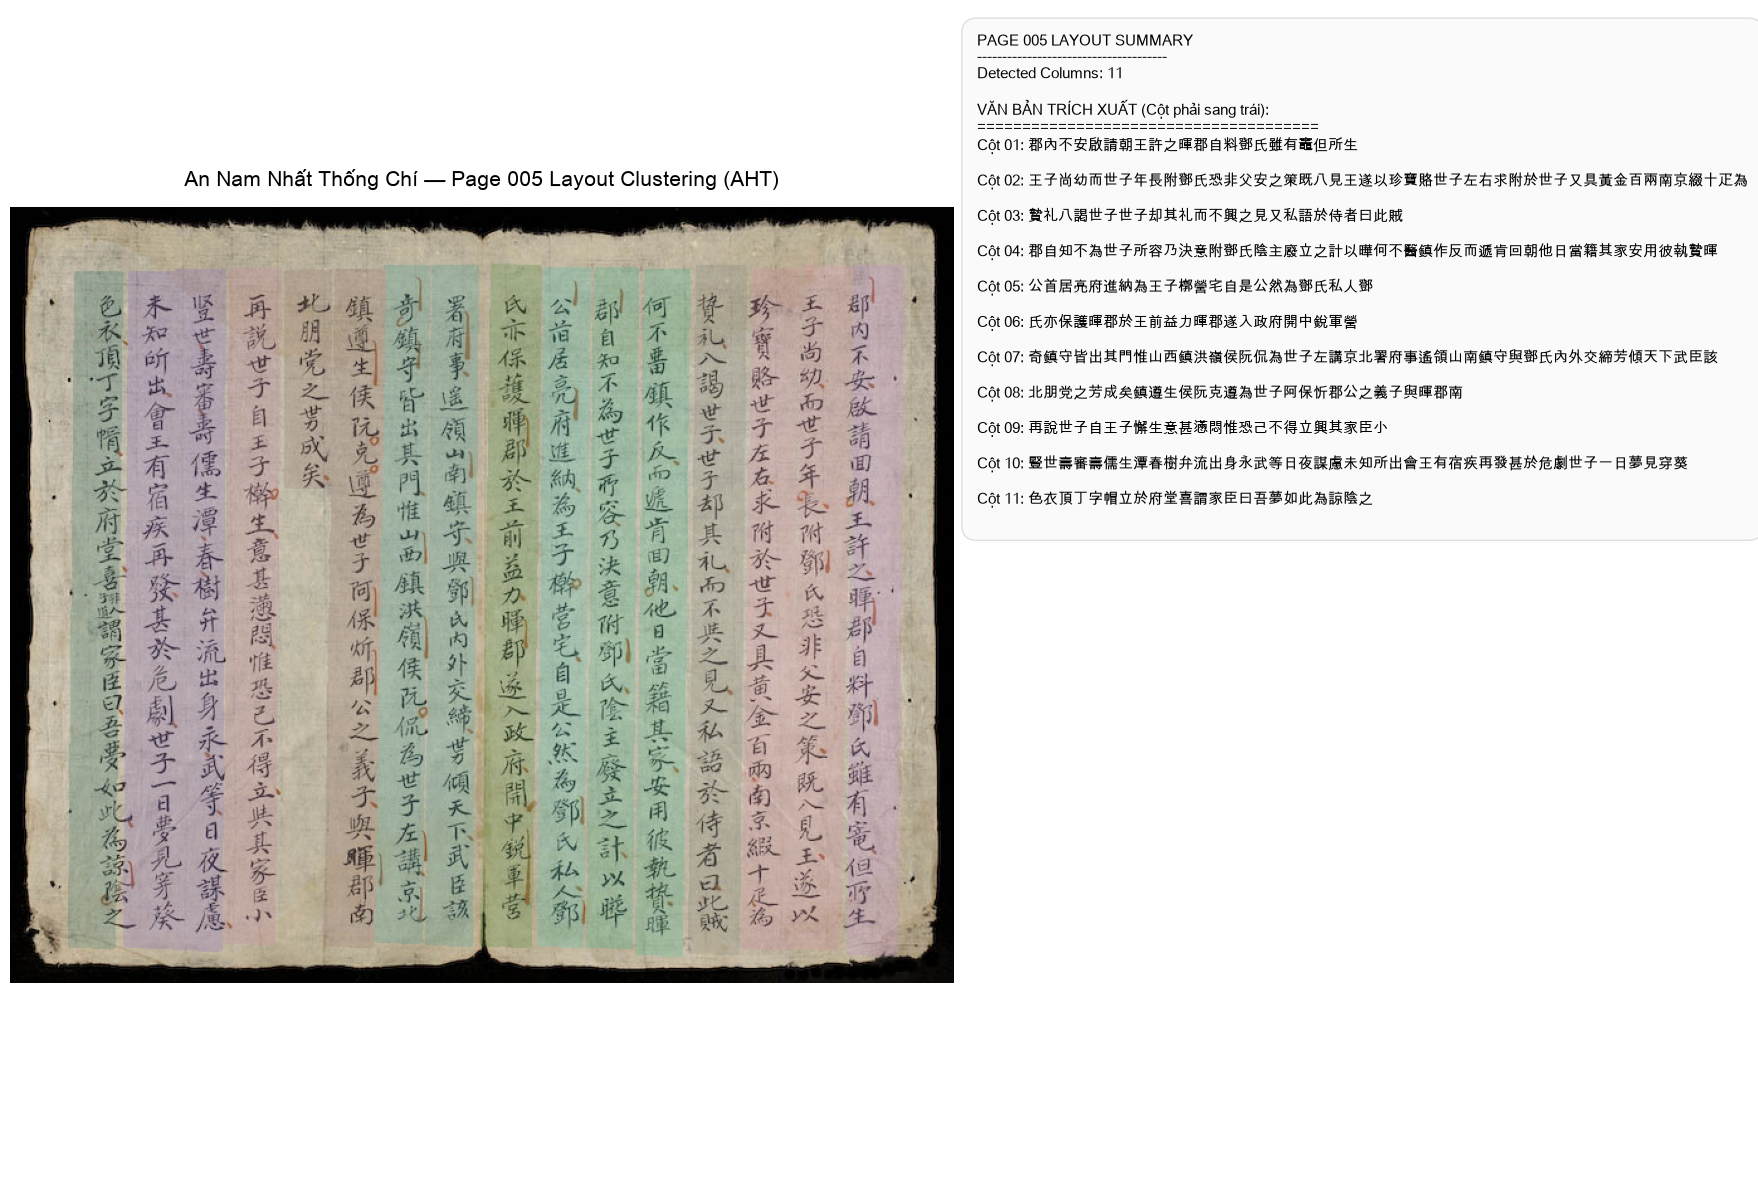

In [20]:
# Change this index to view any page (1 to 107)
visualize_page_layout(page_num=5)